# Sprint EAL — Formación en las empresas · Eje **MEDIOS**
### Data Understanding + EDA de la tabla EAL-18a (Encuesta Anual Laboral, MITES)

**Equip 33 · Simulador IT Academy** — analista: *Nix (nixxx10)*

---

**Pregunta de negocio del Sprint:** cómo ajustar las políticas de formación de la organización para alinearlas con las tendencias del sector, atendiendo a **competencias clave, medios utilizados y barreras**.

**Alcance de este notebook (mi parte):** el eje de **MEDIOS de formación** — la tabla **EAL-18a** *("Empresas que proporcionaron formación a sus trabajadores, según medio utilizado")*. Aquí hago el **Data Understanding**, la **limpieza a formato tidy** y el **EDA de distribución** según los cruces que la fuente permite.

**Dimensiones acordadas con el equipo:** temporal 2022-2024 · geográfica Nacional · sector Transporte/Servicios · tamaño +499 trabajadores. Para *medios*, tras corregir una incidencia con los ficheros de origen, disponemos de **dos años (2023 y 2024)** — 2022 no incluye esta tabla —, y el cruce tamaño×sector no es simultáneo. Todo ello queda documentado en el Data Understanding.

## 1. Configuración e imports

Cargamos librerías y fijamos un estilo de gráficos coherente con la guía de visualización del equipo (paleta *colorblind-safe*, tinta sobria, sin ruido de rejilla).

In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt

# --- Paleta categórica validada (5 medios -> 5 slots, orden fijo) ---
CAT   = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.dpi": 110, "font.family": "DejaVu Sans", "font.size": 10,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": False,
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.max_colwidth", 60)
print("Entorno listo.")

Entorno listo.


## 2. Carga de datos

Vanessa dejó en el repo los **tres libros crudos** de la EAL en `Data/Encuesta_EAL/Raw_2022-2024/`. Localizamos la carpeta de forma robusta (el notebook vive en `Scripts/`, así que subimos a `../Data/...`) y listamos las hojas de cada libro.

In [2]:
def encontrar_raw():
    candidatos = [
        Path("../Data/Encuesta_EAL/Raw_2022-2024"),
        Path("Data/Encuesta_EAL/Raw_2022-2024"),
        Path("../../Data/Encuesta_EAL/Raw_2022-2024"),
        Path.cwd(),
    ]
    for c in candidatos:
        if (c / "Tablas_EAL_2024.xlsx").exists():
            return c.resolve()
    raise FileNotFoundError("No encuentro Raw_2022-2024; ajusta la ruta manualmente en RAW_DIR.")

RAW_DIR = encontrar_raw()
PROC_DIR = (RAW_DIR.parent / "processed")
FICHEROS = {"2022": "Tablas_EAL_2022.xlsx", "2023": "Tablas_EAL_2023.xlsx", "2024": "Tablas_EAL_2024.xlsx"}
print("Carpeta raw:", RAW_DIR)

for etq, fn in FICHEROS.items():
    wb = openpyxl.load_workbook(RAW_DIR / fn, read_only=True)
    print(f"  {fn}: {len(wb.sheetnames)} hojas | ¿tiene EAL-18a?  {'EAL-18a' in wb.sheetnames}")
    wb.close()

Carpeta raw: /tmp/pd_probe/Equip_33/Data/Encuesta_EAL/Raw_2022-2024
  Tablas_EAL_2022.xlsx: 57 hojas | ¿tiene EAL-18a?  False


  Tablas_EAL_2023.xlsx: 53 hojas | ¿tiene EAL-18a?  True
  Tablas_EAL_2024.xlsx: 53 hojas | ¿tiene EAL-18a?  True


## 3. Data Understanding

La EAL no publica microdatos abiertos: son **tablas ya agregadas** (porcentajes) cruzadas por tamaño, actividad económica y CCAA. La tabla que nos ocupa, **EAL-18a**, recoge el **% de empresas (sobre las que formaron) que usaron cada medio** de formación. Es una pregunta de **respuesta múltiple** (una empresa puede usar varios medios), así que **los porcentajes no suman 100**.

### 3.1 Calidad de datos: una incidencia detectada y corregida

Al explorar los ficheros detectamos que el libro `Tablas_EAL_2024.xlsx` llegó inicialmente **duplicado** del de 2023 (mismo contenido, año de referencia 2023). Se corrigió y se re-subió el fichero **auténtico** de 2024. Aquí verificamos programáticamente el estado actual: año de referencia de cada libro, si son ficheros distintos, y para qué años tenemos la tabla de medios.

In [3]:
def cabecera_18a(path):
    wb = openpyxl.load_workbook(path, read_only=True, data_only=True)
    if "EAL-18a" not in wb.sheetnames:
        wb.close(); return None, None
    ws = wb["EAL-18a"]
    filas = [list(r) for r in ws.iter_rows(values_only=True)]
    wb.close()
    ref = None
    for r in filas[:8]:
        for c in r:
            m = re.search(r"Año\s+(\d{4})", str(c) if c is not None else "")
            if m: ref = m.group(1)
    return ref, filas

resumen = {}
for etq, fn in FICHEROS.items():
    ref, filas = cabecera_18a(RAW_DIR / fn)
    resumen[etq] = (ref, filas)
    print(f"{fn:24s} -> tabla EAL-18a: {'AUSENTE' if filas is None else 'presente'} | año de referencia: {ref}")

# (a) ¿Son el MISMO fichero, bit a bit? -> MD5 del libro completo
import hashlib
md5 = {etq: hashlib.md5((RAW_DIR / fn).read_bytes()).hexdigest() for etq, fn in FICHEROS.items()}
for etq in FICHEROS:
    print(f"  MD5 {FICHEROS[etq]:24s}: {md5[etq]}")
print("  ¿'2023' y '2024' son el mismo fichero?", md5["2023"] == md5["2024"])

# (b) ¿Qué años 'Año XXXX' aparecen en las cabeceras de cada libro?
def años_en_cabeceras(path):
    wb = openpyxl.load_workbook(path, read_only=True, data_only=True)
    años = set()
    for sh in wb.sheetnames:
        for i, row in enumerate(wb[sh].iter_rows(values_only=True)):
            if i > 7: break
            for c in row:
                años.update(re.findall(r"Año\s+(\d{4})", str(c) if c is not None else ""))
    wb.close(); return sorted(años)

print()
for etq, fn in FICHEROS.items():
    print(f"  {fn:24s}: años presentes -> {años_en_cabeceras(RAW_DIR / fn)}")

# Comprobación de la corrección: la edición EAL-2024 oficial reporta 'Año 2024'.
print("\n  ¿El fichero '2024' contiene ya un 'Año 2024'?",
      "2024" in años_en_cabeceras(RAW_DIR / FICHEROS["2024"]))

# ¿Para qué años tenemos realmente la tabla de medios (EAL-18a)?
años_medios = sorted({resumen[e][0] for e in FICHEROS if resumen[e][1] is not None})
print("  Años con tabla de medios (EAL-18a):", años_medios)

Tablas_EAL_2022.xlsx     -> tabla EAL-18a: AUSENTE | año de referencia: None
Tablas_EAL_2023.xlsx     -> tabla EAL-18a: presente | año de referencia: 2023


Tablas_EAL_2024.xlsx     -> tabla EAL-18a: presente | año de referencia: 2024
  MD5 Tablas_EAL_2022.xlsx    : 5407e8607b48e7e5e2e7d8c9a0256e83
  MD5 Tablas_EAL_2023.xlsx    : 4d5de7ce397a70bcadbea898bed7126b
  MD5 Tablas_EAL_2024.xlsx    : dd5394afa277d740dca89e21c7661145
  ¿'2023' y '2024' son el mismo fichero? False



  Tablas_EAL_2022.xlsx    : años presentes -> ['2022']


  Tablas_EAL_2023.xlsx    : años presentes -> ['2022', '2023']


  Tablas_EAL_2024.xlsx    : años presentes -> ['2022', '2024']



  ¿El fichero '2024' contiene ya un 'Año 2024'? True
  Años con tabla de medios (EAL-18a): ['2023', '2024']


> **Conclusión de calidad de datos.**
> - `Tablas_EAL_2022.xlsx` **no contiene** la tabla de medios (EAL-18a): en esa edición ese desglose no existe.
> - `Tablas_EAL_2023.xlsx` (año ref. **2023**) y `Tablas_EAL_2024.xlsx` (año ref. **2024**) son ahora **ficheros distintos** (MD5 diferente) y sus cifras de 2024 coinciden con el resumen oficial del MITES. La incidencia del duplicado quedó resuelta.
> - *Contexto:* inicialmente el fichero "2024" llegó como copia del de 2023 (por eso el análisis previo era un único corte). Se re-subió el correcto.
>
> **Implicación:** para el eje de *medios* disponemos de **dos años reales: 2023 y 2024** (2022 no trae EAL-18a). Por tanto **sí es posible una comparación temporal**, aunque corta (dos puntos) y sin 2022. Trabajamos ambos años; para los cruces por tamaño y sector usamos la edición más reciente (**2024**).

### 3.2 Estructura de la tabla EAL-18a

La tabla tiene una fila `TOTAL` y tres bloques de desglose (**tamaño de empresa**, **actividad económica** y **comunidad autónoma**), y en columnas los **5 medios** de formación. Los inspeccionamos.

In [4]:
ref, filas = resumen["2024"]
# fila de cabecera (contiene 'TOTAL (2)') y etiquetas de los 5 medios
hrow = next(i for i,r in enumerate(filas) if len(r)>1 and r[1] and "TOTAL" in str(r[1]).upper())
medios_largos = [str(filas[hrow][2+k]).strip() for k in range(5)]
print("Los 5 MEDIOS (columnas):")
for k, m in enumerate(medios_largos, 1):
    print(f"  {k}. {m}")

# etiquetas de fila = niveles de cada cruce
secciones = {"TAMAÑO DE LA EMPRESA":"Tamaño","ACTIVIDAD ECONÓMICA":"Sector","COMUNIDAD AUTÓNOMA":"CCAA"}
bloque, niveles = "Total", {"Total":[], "Tamaño":[], "Sector":[], "CCAA":[]}
for r in filas[hrow+1:]:
    lab = "" if r[0] is None else str(r[0]).strip()
    if not lab: continue
    if lab.upper() in secciones: bloque = secciones[lab.upper()]; continue
    if lab.startswith("(") or lab.startswith("Fuente"): break
    niveles[bloque].append(lab)
for b, ns in niveles.items():
    print(f"\nCruce '{b}': {len(ns) if b!='Total' else 1} nivel(es)")
    if b != "Total": print("   ", " · ".join(n[:28] for n in ns))

Los 5 MEDIOS (columnas):
  1. Cursos de formación  diseñados y gestionados por su empresa
  2. Cursos de formación diseñados y gestionados por otra organización
  3. Formación planificada en el puesto de trabajo, utilizando los medios habituales de trabajo
  4. Aprendizaje planificado a partir de rotación de puestos de trabajo, intercambios, etc.
  5. Participación en conferencias, seminarios, grupos de trabajo, talleres o ferias de muestras

Cruce 'Total': 1 nivel(es)

Cruce 'Tamaño': 5 nivel(es)
    De 5 a 9 trabajadores · De 10 a 49 trabajadores · De 50 a 249 trabajadores · De 250 a 499 trabajadores · Más de 499 trabajadores

Cruce 'Sector': 9 nivel(es)
    Industria · Construcción · Comercio y reparación de veh · Transporte y almacenamiento · Hostelería · Información, comunicaciones, · Actividades profesionales, c · Actividades administrativas  · Actividades artísticas, recr

Cruce 'CCAA': 17 nivel(es)
    Andalucía · Aragón · Asturias (Principado de) · Balears (Illes) · Canarias ·

## 4. Limpieza y reestructuración a formato *tidy*

Pasamos la tabla de formato ancho (medios en columnas, cruces mezclados en filas) a **formato largo**, una fila por combinación:

`anio · tipo_cruce · valor_cruce · medio · porcentaje`

Nos quedamos con las **5 columnas de medios** (base común: *empresas que formaron*) y descartamos la columna auxiliar `TOTAL (2)`, cuya base es distinta (*total de empresas*), para no mezclar bases. El resultado se guarda en `processed/` para alimentar Power BI.

In [5]:
MEDIO_MAP = {0:"Cursos propios", 1:"Cursos externos", 2:"Formación en el puesto",
             3:"Rotación / intercambios", 4:"Conferencias / seminarios"}
SECCIONES = {"TAMAÑO DE LA EMPRESA":"Tamaño", "ACTIVIDAD ECONÓMICA":"Sector", "COMUNIDAD AUTÓNOMA":"CCAA"}

def parsear_18a(path):
    """Devuelve la tabla EAL-18a en formato tidy (o None si no existe en ese libro)."""
    wb = openpyxl.load_workbook(path, read_only=True, data_only=True)
    if "EAL-18a" not in wb.sheetnames:
        wb.close(); return None
    ws = wb["EAL-18a"]; filas = [list(r) for r in ws.iter_rows(values_only=True)]; wb.close()
    ref = None
    for r in filas[:8]:
        for c in r:
            m = re.search(r"Año\s+(\d{4})", str(c) if c is not None else "")
            if m: ref = m.group(1)
    hrow = next(i for i,r in enumerate(filas) if len(r)>1 and r[1] and "TOTAL" in str(r[1]).upper())
    recs, cruce = [], "Total"
    for r in filas[hrow+1:]:
        lab = "" if r[0] is None else str(r[0]).strip()
        if not lab: continue
        if lab.upper() in SECCIONES: cruce = SECCIONES[lab.upper()]; continue
        if lab.startswith("(") or lab.startswith("Fuente"): break
        vals = r[2:7]
        if all(v is None for v in vals): continue
        valor = "Total" if cruce == "Total" else lab
        for k in range(5):
            if isinstance(vals[k], (int, float)):
                recs.append({"anio": ref, "tipo_cruce": cruce, "valor_cruce": valor,
                             "medio": MEDIO_MAP[k], "porcentaje": round(float(vals[k]), 2)})
    return pd.DataFrame(recs)

# Parseamos las ediciones que SÍ traen la tabla de medios (2023 y 2024)
frames = [parsear_18a(RAW_DIR / FICHEROS[a]) for a in ["2023", "2024"]]
medios = pd.concat([f for f in frames if f is not None], ignore_index=True)
ULTIMO = medios["anio"].max()          # edición más reciente, para los cortes por tamaño/sector
print("Formato tidy:", medios.shape, "| años:", sorted(medios.anio.unique()), "| más reciente:", ULTIMO)
display(medios.head(8))
print("\nFilas por (año, tipo de cruce):")
print(medios.groupby(["anio","tipo_cruce"]).size())

Formato tidy: (320, 5) | años: ['2023', '2024'] | más reciente: 2024


,anio,tipo_cruce,valor_cruce,medio,porcentaje
0,2023,Total,Total,Cursos propios,33.51
1,2023,Total,Total,Cursos externos,72.12
2,2023,Total,Total,Formación en el puesto,58.49
3,2023,Total,Total,Rotación / intercambios,26.92
4,2023,Total,Total,Conferencias / seminarios,34.06
5,2023,Tamaño,De 5 a 9 trabajadores,Cursos propios,27.45
6,2023,Tamaño,De 5 a 9 trabajadores,Cursos externos,66.50
7,2023,Tamaño,De 5 a 9 trabajadores,Formación en el puesto,54.60



Filas por (año, tipo de cruce):
anio  tipo_cruce
2023  CCAA          85
      Sector        45
      Tamaño        25
      Total          5
2024  CCAA          85
      Sector        45
      Tamaño        25
      Total          5
dtype: int64


In [6]:
# Control de calidad rápido del tidy
print("Nulos por columna:\n", medios.isna().sum(), "\n")
print("Rango de porcentaje:", medios.porcentaje.min(), "-", medios.porcentaje.max())
print("Medios:", list(medios.medio.unique()))
print("\n% TOTAL nacional por medio y año:")
display(medios[medios.tipo_cruce=="Total"].pivot(index="medio", columns="anio", values="porcentaje").round(1))

# Slice de la edición más reciente, para los cortes por tamaño y sector
m = medios[medios.anio == ULTIMO].copy()

# Guardar en processed/ para Power BI (dos años, formato largo)
PROC_DIR.mkdir(parents=True, exist_ok=True)
salida = PROC_DIR / "EAL18a_medios_tidy_2023-2024.csv"
medios.to_csv(salida, index=False, encoding="utf-8-sig")
print("\nGuardado:", salida, "->", len(medios), "filas")

Nulos por columna:
 anio           0
tipo_cruce     0
valor_cruce    0
medio          0
porcentaje     0
dtype: int64 

Rango de porcentaje: 13.13 - 85.89
Medios: ['Cursos propios', 'Cursos externos', 'Formación en el puesto', 'Rotación / intercambios', 'Conferencias / seminarios']

% TOTAL nacional por medio y año:


anio,2023,2024
medio,,
Conferencias / seminarios,34.1,35.1
Cursos externos,72.1,73.7
Cursos propios,33.5,34.3
Formación en el puesto,58.5,56.0
Rotación / intercambios,26.9,27.4



Guardado: /tmp/pd_probe/Equip_33/Data/Encuesta_EAL/processed/EAL18a_medios_tidy_2023-2024.csv -> 320 filas


## 5. EDA — Análisis de distribución

Recordatorio: cada valor es el **% de empresas (que formaron) que usaron ese medio**; al ser respuesta múltiple, **no suman 100** — comparamos medios entre sí, no como partes de un todo.

### 5.1 ¿Qué medios se usan más? Distribución total y evolución 2023 → 2024

Distribución global de los cinco medios, comparando las dos ediciones disponibles.

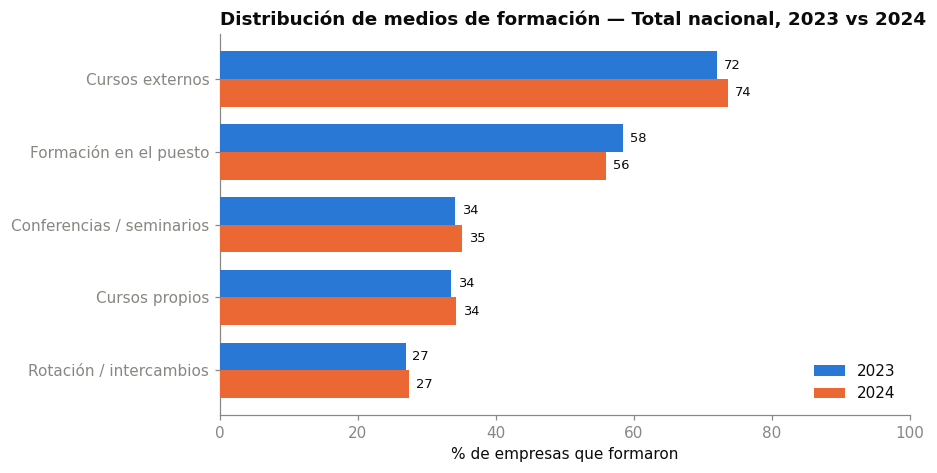

In [7]:
MED_ORDER = list(MEDIO_MAP.values())
piv = (medios[medios.tipo_cruce=="Total"]
       .pivot(index="medio", columns="anio", values="porcentaje").loc[MED_ORDER])
orden = list(piv[ULTIMO].sort_values().index)     # ordenar por el año más reciente
piv = piv.loc[orden]
años = list(piv.columns)

y = np.arange(len(orden)); h = 0.38
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.barh(y + h/2, piv[años[0]].values, h, label=años[0], color="#2a78d6", zorder=3)
ax.barh(y - h/2, piv[años[1]].values, h, label=años[1], color="#eb6834", zorder=3)
for yy, v0, v1 in zip(y, piv[años[0]].values, piv[años[1]].values):
    ax.text(v0 + 1, yy + h/2, f"{v0:.0f}", va="center", fontsize=8.5, color=INK)
    ax.text(v1 + 1, yy - h/2, f"{v1:.0f}", va="center", fontsize=8.5, color=INK)
ax.set_yticks(y); ax.set_yticklabels(orden)
ax.set_xlim(0, 100); ax.set_xlabel("% de empresas que formaron")
ax.set_title("Distribución de medios de formación — Total nacional, 2023 vs 2024",
             fontsize=12, weight="bold", loc="left")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

**Lectura.** El orden es claro y **estable entre 2023 y 2024**: dominan los **cursos externos** (72% → 74%) y la **formación en el puesto** (58% → 56%); **cursos propios** y **conferencias** rondan el 34-35%, y la **rotación/intercambios** es el medio minoritario (~27%). Los movimientos interanuales son pequeños; el más reseñable es un ligero **retroceso de la formación en el puesto** (−2,5 pp) frente a subidas leves en el resto. Con solo dos puntos hablamos de **estabilidad**, no de una tendencia consolidada.

> **⚠️ Cómo se lee este porcentaje (importante).** Cada barra es el **% de empresas (que formaron) que usaron ese medio** — *penetración*, no reparto. Al ser una pregunta de **respuesta múltiple**, los valores **no suman 100** (aquí suman ~225%): una misma empresa se cuenta en varios medios a la vez.
>
> El registro es **binario (sí/no)** por medio: sabemos *qué* medios están presentes en cada empresa, **no existen pesos ni intensidad**. La EAL no dice cuántas acciones formativas hizo la empresa, a cuántos trabajadores, ni qué fracción de su formación representa cada medio. Por eso esto es un **ranking de penetración de cada medio**, y **no** un gráfico de partes de un todo (nada de tartas ni de "cuota interna" por empresa).

### 5.1.1 ¿El cambio 2023 → 2024 es señal o ruido? (z-test de proporciones)

Como buena práctica —y para ser **coherentes con el análisis de barreras**, que aplica el mismo contraste— comprobamos si las variaciones interanuales son estadísticamente fiables o simple ruido muestral, con un **z-test de comparación de proporciones** (α = 0,05).

**Un matiz de base importante:** EAL-18a se calcula **sobre las empresas formadoras**, no sobre el total de empresas. Por tanto el N del test debe ser el de *formadoras*. Lo derivamos de **nuestra propia tabla**: `N_formadoras = muestra nacional × tasa de formación`, donde la tasa de formación es justo la columna **`TOTAL (2)`** de EAL-18a (≈73%). (La muestra nacional total procede del *Informe Metodológico Estandarizado* de la EAL, único sitio donde se publica el n absoluto.)

In [8]:
from statsmodels.stats.proportion import proportions_ztest

# El N debe corresponder a la BASE de la tabla: empresas FORMADORAS (no el total).
N_TOTAL = {"2023": 9982, "2024": 9767}   # muestra nacional (Informe Metodológico Estandarizado EAL)

def tasa_formacion(anio):
    """% de empresas que forman = columna TOTAL(2) de la fila TOTAL de EAL-18a (de la propia tabla)."""
    fil = resumen[anio][1]
    hr = next(i for i,r in enumerate(fil) if len(r)>1 and r[1] and "TOTAL" in str(r[1]).upper())
    for r in fil[hr+1:]:
        if r[0] and str(r[0]).strip().upper() == "TOTAL":
            return float(r[1])

N_FORM = {a: round(N_TOTAL[a] * tasa_formacion(a) / 100) for a in N_TOTAL}
print("Tasa de formación (col. TOTAL(2)):", {a: round(tasa_formacion(a),1) for a in N_TOTAL}, "%")
print("N formadoras (base del test):", N_FORM)

def test_proporciones(pct_a, n_a, pct_b, n_b):
    """z-test de dos proporciones a partir de porcentajes agregados y su tamaño muestral."""
    conteos = [round(pct_a * n_a / 100), round(pct_b * n_b / 100)]
    _, p = proportions_ztest(conteos, [n_a, n_b])
    return p

tot_ab = (medios[medios.tipo_cruce=="Total"]
          .pivot(index="medio", columns="anio", values="porcentaje").loc[MED_ORDER])
filas = []
for me in MED_ORDER:
    a, b = tot_ab.loc[me, "2023"], tot_ab.loc[me, "2024"]
    p = test_proporciones(a, N_FORM["2023"], b, N_FORM["2024"])
    filas.append({"medio": me, "pct_2023": a, "pct_2024": b, "delta_pp": round(b - a, 1),
                  "p_valor": round(p, 4), "significativo_alfa0.05": "sí" if p < 0.05 else "no"})
ztest = pd.DataFrame(filas)
display(ztest)

ztest.to_csv(PROC_DIR / "EAL18a_medios_ztest_2023-2024.csv", index=False, encoding="utf-8-sig")
print("Guardado:", PROC_DIR / "EAL18a_medios_ztest_2023-2024.csv")

Tasa de formación (col. TOTAL(2)): {'2023': 72.9, '2024': 73.5} %
N formadoras (base del test): {'2023': 7280, '2024': 7176}


,medio,pct_2023,pct_2024,delta_pp,p_valor,significativo_alfa0.05
0,Cursos propios,33.51,34.27,0.8,0.3405,no
1,Cursos externos,72.12,73.71,1.6,0.0317,sí
2,Formación en el puesto,58.49,56.01,-2.5,0.0026,sí
3,Rotación / intercambios,26.92,27.38,0.5,0.5342,no
4,Conferencias / seminarios,34.06,35.09,1.0,0.1959,no


Guardado: /tmp/pd_probe/Equip_33/Data/Encuesta_EAL/processed/EAL18a_medios_ztest_2023-2024.csv


**Lectura.** Con la base correcta (formadoras, N≈7.200), **dos** cambios siguen siendo significativos — **formación en el puesto** (−2,5 pp, p≈0,003) y **cursos externos** (+1,6 pp, p≈0,032) —; cursos propios, conferencias y rotación **no** lo son. Al usar el N adecuado (menor que la muestra total) los p-valores suben un poco, pero las conclusiones no cambian. Y el matiz de fondo se mantiene: con miles de empresas hasta 1–2 pp resultan detectables, así que lo relevante es que **la magnitud es mínima** — el patrón de medios es **esencialmente estable** 2023→2024, con un leve trasvase de formación en el puesto hacia los cursos externos. *(El n absoluto viene del Informe Metodológico y el test no ajusta por el diseño muestral, así que el p-valor es orientativo.)*

### 5.2 El efecto del tamaño de empresa (foco +499)

Nuestra organización de referencia es grande (**+499 trabajadores**). Con la edición más reciente (**2024**) comparamos ese tramo con el total y vemos cómo escala el uso de cada medio con el tamaño.

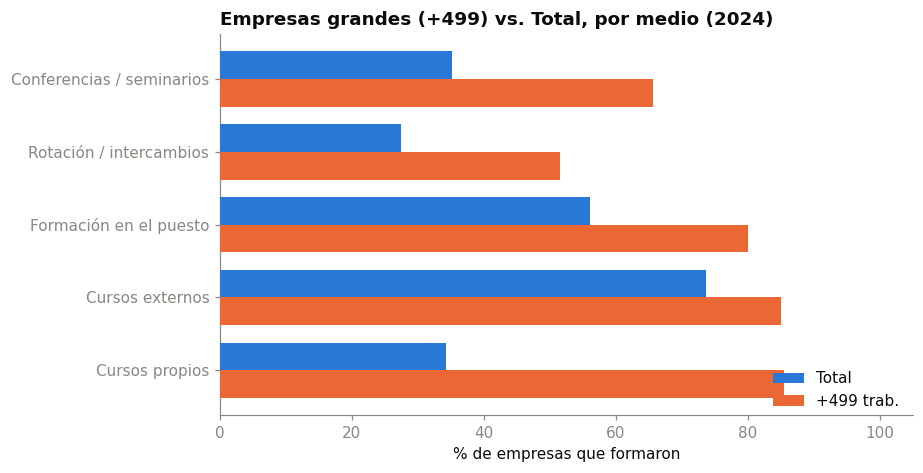

In [9]:
tot = m[m.tipo_cruce=="Total"].set_index("medio")["porcentaje"]
g499 = (m[(m.tipo_cruce=="Tamaño") & (m.valor_cruce=="Más de 499 trabajadores")]
        .set_index("medio")["porcentaje"])

y = np.arange(len(MED_ORDER)); h = 0.38
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.barh(y + h/2, [tot[me]  for me in MED_ORDER], h, label="Total",      color="#2a78d6", zorder=3)
ax.barh(y - h/2, [g499[me] for me in MED_ORDER], h, label="+499 trab.", color="#eb6834", zorder=3)
ax.set_yticks(y); ax.set_yticklabels(MED_ORDER)
ax.set_xlim(0, 105); ax.set_xlabel("% de empresas que formaron")
ax.set_title(f"Empresas grandes (+499) vs. Total, por medio ({ULTIMO})",
             fontsize=12, weight="bold", loc="left")
ax.legend(frameon=False, loc="lower right", bbox_to_anchor=(1, -0.02))
plt.tight_layout(); plt.show()

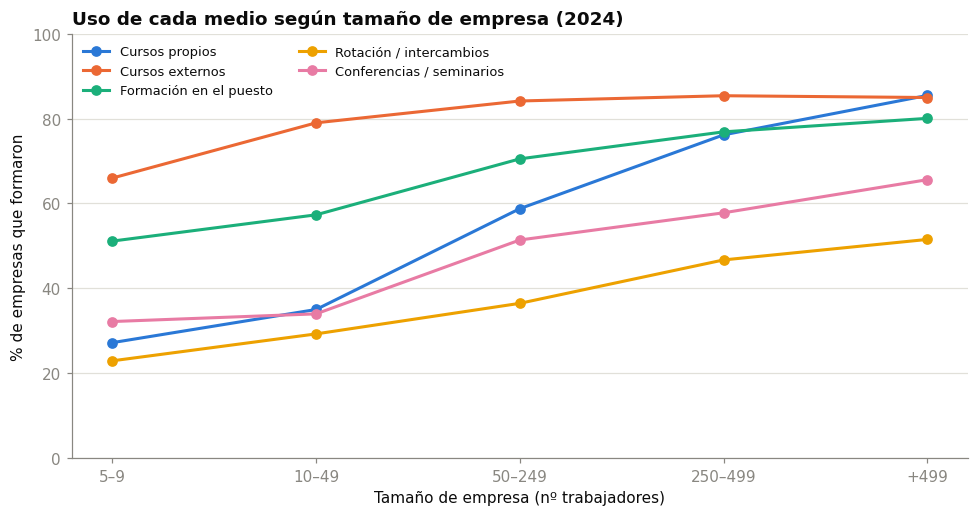

In [10]:
SIZE_ORDER = ["De 5 a 9 trabajadores","De 10 a 49 trabajadores","De 50 a 249 trabajadores",
              "De 250 a 499 trabajadores","Más de 499 trabajadores"]
SIZE_SHORT = ["5–9","10–49","50–249","250–499","+499"]

fig, ax = plt.subplots(figsize=(9, 4.8))
for k, me in enumerate(MED_ORDER):
    ser = (m[(m.tipo_cruce=="Tamaño") & (m.medio==me)]
           .set_index("valor_cruce")["porcentaje"].loc[SIZE_ORDER])
    ax.plot(SIZE_SHORT, ser.values, marker="o", color=CAT[k], lw=2, ms=6, label=me, zorder=3)
ax.set_ylim(0, 100); ax.set_xlabel("Tamaño de empresa (nº trabajadores)")
ax.set_ylabel("% de empresas que formaron")
ax.grid(axis="y", color=GRID, zorder=0)
ax.set_title(f"Uso de cada medio según tamaño de empresa ({ULTIMO})",
             fontsize=12, weight="bold", loc="left")
ax.legend(frameon=False, fontsize=8.5, ncol=2, loc="upper left")
plt.tight_layout(); plt.show()

**Lectura.** El tamaño lo cambia todo. Las empresas de **+499 usan más *todos* los medios**, pero el salto es especialmente grande en los que exigen estructura interna: **cursos propios** pasan de ~34% (total) a **~85%**, y las **conferencias** de ~35% a **~66%**. La **formación en el puesto** llega al ~80% y la **rotación** al ~52% (frente al 27% del total). En la práctica, una organización grande no elige *un* medio: **combina todos**. El gradiente por tamaño es monótono creciente en los cinco medios, lo que refuerza que la capacidad formativa está muy ligada al tamaño.

### 5.3 El perfil por sector (Transporte y Servicios)

Por último, el cruce por actividad económica. La tabla trae las 9 ramas; resaltamos **Transporte y almacenamiento**, dentro del gran agregado de **Servicios**.

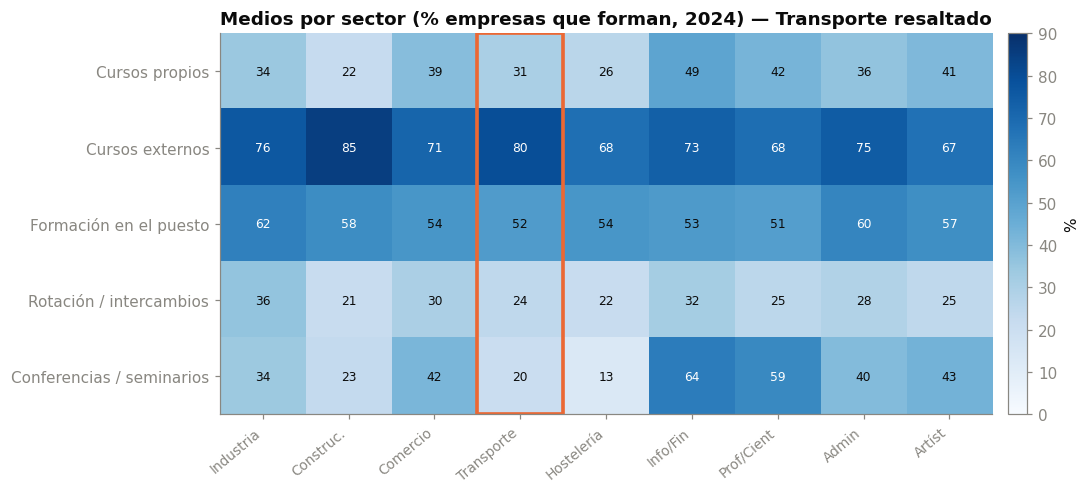

In [11]:
SECT_SHORT = {
 "Industria":"Industria", "Construcción":"Construc.",
 "Comercio y reparación de vehículos":"Comercio", "Transporte y almacenamiento":"Transporte",
 "Hostelería":"Hostelería",
 "Información, comunicaciones, actividades financieras, de seguros e inmobiliarias":"Info/Fin",
 "Actividades profesionales, científicas y técnicas":"Prof/Cient",
 "Actividades administrativas y servicios auxiliares":"Admin",
 "Actividades artísticas, recreativas y de entretenimiento y otros servicios":"Artíst"}
ORDER = ["Industria","Construc.","Comercio","Transporte","Hostelería","Info/Fin","Prof/Cient","Admin","Artíst"]

sec = (m[m.tipo_cruce=="Sector"]
       .pivot(index="medio", columns="valor_cruce", values="porcentaje")
       .loc[MED_ORDER].rename(columns=SECT_SHORT)[ORDER])

fig, ax = plt.subplots(figsize=(10, 4.6))
im = ax.imshow(sec.values, cmap="Blues", aspect="auto", vmin=0, vmax=90)
ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER, rotation=40, ha="right", fontsize=9)
ax.set_yticks(range(len(MED_ORDER))); ax.set_yticklabels(MED_ORDER)
for i in range(sec.shape[0]):
    for j in range(sec.shape[1]):
        v = sec.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8,
                color="white" if v > 55 else INK)
ti = ORDER.index("Transporte")
ax.add_patch(plt.Rectangle((ti-0.5, -0.5), 1, len(MED_ORDER), fill=False, edgecolor="#eb6834", lw=2.4))
ax.set_title(f"Medios por sector (% empresas que forman, {ULTIMO}) — Transporte resaltado",
             fontsize=12, weight="bold", loc="left")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02).set_label("%")
plt.tight_layout(); plt.show()

**Lectura.** **Transporte y almacenamiento** dibuja un perfil claro: es **fuerte en cursos externos (~80%)** — de los más altos — pero **el más bajo de todos los sectores en conferencias/seminarios (~20%)** y muy bajo en rotación (~24%). Es decir, un sector que externaliza la formación reglada pero apenas usa formatos de desarrollo "blando" (redes, seminarios, rotación). El contraste es nítido con los servicios intensivos en conocimiento — **Información/Finanzas** (~64%) y **Profesionales/científicas** (~59%) — donde las conferencias son mucho más frecuentes. Para una recomendación de negocio en el sector servicios/transporte, ahí hay una **palanca poco explotada**.

## 6. Conclusiones y limitaciones

**Hallazgos del eje MEDIOS (2023-2024):**
1. La formación empresarial se apoya sobre todo en **cursos externos** (~72-74%) y **formación en el puesto** (~56-58%); la **rotación** es residual (~27%). El patrón es **estable entre 2023 y 2024**, con un leve retroceso de la formación en el puesto.
2. El **tamaño** es el factor más determinante: las empresas de **+499** usan todos los medios mucho más, y sobre todo desarrollan **capacidad interna** (cursos propios ~85%, conferencias ~66%, formación en el puesto ~80%).
3. **Transporte/Servicios** externaliza bien la formación reglada pero **infrautiliza conferencias y rotación** frente a otros servicios (conferencias ~20% vs ~60% en Info/Finanzas y Profesionales) — palanca de mejora.

**Limitaciones (importantes para el equipo):**
- **Serie temporal corta:** disponemos de **2023 y 2024** (2022 no trae EAL-18a), así que hablamos de estabilidad interanual, no de tendencia consolidada. *(Nota: el fichero 2024 llegó inicialmente duplicado del 2023; se detectó y corrigió.)*
- **Sin cruce tamaño × sector:** la EAL da marginales, no el cruce combinado. "+499" y "Transporte/Servicios" se analizan como **lentes separadas**, no simultáneas. Los cortes por tamaño y sector usan la edición más reciente (2024).
- **Respuesta múltiple, sin pesos:** los porcentajes son penetración (% de empresas por medio, registro binario sí/no), no suman 100 y no reflejan intensidad ni cuota interna por empresa; se interpretan medio a medio.

**Salida generada:** `Data/Encuesta_EAL/processed/EAL18a_medios_tidy_2023-2024.csv` — formato largo (dos años) listo para Power BI.